<a href="https://colab.research.google.com/github/francorte/cafa6-protein-function-prediction/blob/main/analisis_mascotas_andalucia_raia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis descriptivo de mascotas registradas en Andalucía

## Objetivo

Analizar la distribución territorial de mascotas registradas en Andalucía por municipio y explorar su relación con variables socioeconómicas como población, renta media y estructura de los hogares.

## Preguntas de análisis

1. ¿Qué municipios tienen mayor número absoluto de mascotas registradas?
2. ¿Qué municipios tienen mayor número de mascotas por cada 1.000 habitantes?
3. ¿Cómo se distribuyen las mascotas por especie entre municipios y provincias?
4. ¿Existe una relación descriptiva entre renta media municipal y mascotas por cada 1.000 habitantes?
5. ¿Los municipios con hogares más pequeños o más hogares unipersonales presentan mayor concentración de mascotas?

In [9]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
import pandas as pd
import json

with open("perros_huelva.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df_perros_huelva = pd.DataFrame(data)

print("Número total de registros:", len(df_perros_huelva))
df_perros_huelva.head()

JSONDecodeError: Extra data: line 425002 column 2 (char 13352858)

In [11]:
with open("perros_huelva.json", "r", encoding="utf-8") as f:
    texto = f.read()

print("Primeros 500 caracteres:")
print(texto[:500])

print("\nÚltimos 500 caracteres:")
print(texto[-500:])

Primeros 500 caracteres:
[
    {
        "identificador": "09e997df9f3df2d0502fc27993aec174e24b4a50",
        "especie": "PERRO",
        "raza": "GOLDEN RETRIEVER",
        "raza2": null,
        "capa": "DORADA",
        "sexo": "MACHO",
        "tamano": "10-20 Kg",
        "fechaNacimiento": "2022-10-10",
        "fechaIdentificacion": null,
        "municipio": "ARACENA",
        "provincia": "Huelva",
        "codigoPostal": "21200",
        "codigoIneLocalidad": "007",
        "codigoIneProvincia": "21",
        

Últimos 500 caracteres:
5-05-15",
        "municipio": "HUELVA",
        "provincia": "Huelva",
        "codigoPostal": "21002",
        "codigoIneLocalidad": "041",
        "codigoIneProvincia": "21",
        "baja": "false"
    },
    {
        "identificador": "d2fe4163363643360483fbfe9081d3f9d20c353a",
        "especie": "PERRO",
        "raza": "PODENCO",
        "raza2": null,
        "capa": "CANELA Y BLANCO",
        "sexo": "HEMBRA",
        "tamano": "5-10 Kg

In [13]:
import json
import pandas as pd

archivo = "perros_huelva.json"

with open(archivo, "r", encoding="utf-8") as f:
    texto = f.read().strip()

decoder = json.JSONDecoder()
pos = 0
registros = []

while pos < len(texto):
    # Saltar espacios, saltos de línea y comas
    while pos < len(texto) and texto[pos] in " \n\r\t,":
        pos += 1

    if pos >= len(texto):
        break

    try:
        obj, pos = decoder.raw_decode(texto, pos)

        if isinstance(obj, list):
            registros.extend(obj)
        elif isinstance(obj, dict):
            registros.append(obj)

    except json.JSONDecodeError:
        # Avanzar hasta el siguiente posible objeto JSON
        siguiente = texto.find("{", pos + 1)
        if siguiente == -1:
            break
        pos = siguiente

df_perros_huelva = pd.DataFrame(registros)

print("Registros leídos:", len(df_perros_huelva))
print("Columnas:", df_perros_huelva.columns.tolist())

df_perros_huelva.head()

Registros leídos: 151647
Columnas: ['identificador', 'especie', 'raza', 'raza2', 'capa', 'sexo', 'tamano', 'fechaNacimiento', 'fechaIdentificacion', 'municipio', 'provincia', 'codigoPostal', 'codigoIneLocalidad', 'codigoIneProvincia', 'baja']


,identificador,especie,raza,raza2,capa,sexo,tamano,fechaNacimiento,fechaIdentificacion,municipio,provincia,codigoPostal,codigoIneLocalidad,codigoIneProvincia,baja
0,09e997df9f3df2d0502fc27993aec174e24b4a50,PERRO,GOLDEN RETRIEVER,None,DORADA,MACHO,10-20 Kg,2022-10-10,None,ARACENA,Huelva,21200,007,21,false
1,080cc04050216703e68885084cea20b0e10985d2,PERRO,GALGO ESPAÑOL,None,CANELA CLARO,HEMBRA,10-20 Kg,2012-11-20,2013-11-28,HUELVA,Huelva,21002,041,21,false
2,8589c6fdf70859bfd0e17639815265860171f9cc,PERRO,CRUZADO,None,GRIS Y BLANCA,HEMBRA,10-20 Kg,2009-11-09,2010-10-06,CORTEGANA,Huelva,21230,025,21,false
3,9aa95535c404a464b5e02f7ce338e89c3df466b3,PERRO,PEQUINES,CRUZADO,CANELA,MACHO,2-5 Kg,2010-03-12,2010-07-21,"ROCIO, EL",Huelva,21750,005,21,false
4,ef0354b60eb33ddf6d4836c86991555f43d32e7d,PERRO,PERRO DE AGUAS ESPAÑOL,None,BICOLOR,HEMBRA,10-20 Kg,2013-07-07,2013-12-12,MINAS DE RIOTINTO,Huelva,21660,049,21,false


In [14]:
df_perros_huelva["municipio"].value_counts().head(20)

,count
municipio,
HUELVA,21360
ALMONTE,8728
VALVERDE DEL CAMINO,7451
MOGUER,5291
CARTAYA,5181
LEPE,4638
ALJARAQUE,4315
BOLLULLOS PAR DEL CONDADO,3924
GIBRALEON,3923


In [15]:
df_aljaraque = df_perros_huelva[
    df_perros_huelva["municipio"].str.upper().str.contains("ALJARAQUE", na=False)
]

print("Número de perros registrados en Aljaraque:", len(df_aljaraque))

df_aljaraque.head()

Número de perros registrados en Aljaraque: 4315


,identificador,especie,raza,raza2,capa,sexo,tamano,fechaNacimiento,fechaIdentificacion,municipio,provincia,codigoPostal,codigoIneLocalidad,codigoIneProvincia,baja
15,3d2d2e7777151f8d44fa583e49079a53327021bc,PERRO,CRUZADO,None,NEGRA Y BLANCA,HEMBRA,5-10 Kg,2011-10-06,2012-03-14,ALJARAQUE,Huelva,21110,002,21,false
42,d05c1348511a98f53e8948d6574ef8fae28e8319,PERRO,CRUZADO,None,"CANELA, BLANCA Y PAR",HEMBRA,5-10 Kg,2006-04-20,2006-08-21,ALJARAQUE,Huelva,21110,002,21,false
68,e2d486f6394eb0201fe17a51c09d205ce8827f68,PERRO,LABRADOR RETRIEVER,None,CHOCOLATE,MACHO,10-20 Kg,2013-07-30,2013-11-21,ALJARAQUE,Huelva,21110,002,21,false
91,1fd51a13428bc807a90234d40fd3b95cadb1f229,PERRO,BULLDOG FRANCES,None,BLANCO C/S ATIGRADO,HEMBRA,10-20 Kg,2012-01-19,2012-04-20,ALJARAQUE,Huelva,21110,002,21,false
134,2e6d34cab8062f068b04b86dba520e576833d637,PERRO,CRUZADO,None,BLANCA Y GRIS,HEMBRA,10-20 Kg,2006-02-15,2011-12-01,ALJARAQUE,Huelva,21110,002,21,false


In [16]:
resumen_perros_huelva = (
    df_perros_huelva
    .groupby("municipio", dropna=False)
    .size()
    .reset_index(name="n_perros")
    .sort_values("n_perros", ascending=False)
)

resumen_perros_huelva.head(20)

,municipio,n_perros
67,HUELVA,21360
9,ALMONTE,8728
136,VALVERDE DEL CAMINO,7451
87,MOGUER,5291
33,CARTAYA,5181
74,LEPE,4638
5,ALJARAQUE,4315
21,BOLLULLOS PAR DEL CONDADO,3924
60,GIBRALEON,3923
111,PUNTA UMBRIA,3222


In [17]:
df_perros_huelva.to_csv("perros_huelva_limpio.csv", index=False)
resumen_perros_huelva.to_csv("resumen_perros_huelva_municipios.csv", index=False)

print("Archivos creados:")
print("perros_huelva_limpio.csv")
print("resumen_perros_huelva_municipios.csv")

Archivos creados:
perros_huelva_limpio.csv
resumen_perros_huelva_municipios.csv


In [18]:
import pandas as pd

resumen_perros_huelva = pd.read_csv("resumen_perros_huelva_municipios.csv")

resumen_perros_huelva.head()

,municipio,n_perros
0,HUELVA,21360
1,ALMONTE,8728
2,VALVERDE DEL CAMINO,7451
3,MOGUER,5291
4,CARTAYA,5181


In [19]:
aljaraque = resumen_perros_huelva[
    resumen_perros_huelva["municipio"].str.upper().str.contains("ALJARAQUE", na=False)
]

aljaraque

,municipio,n_perros
6,ALJARAQUE,4315


In [20]:
n_perros_aljaraque = int(aljaraque["n_perros"].iloc[0])

print(f"Número de perros registrados en Aljaraque: {n_perros_aljaraque}")

Número de perros registrados en Aljaraque: 4315


In [22]:
from IPython.display import Markdown, display

n_perros_aljaraque = int(aljaraque["n_perros"].iloc[0])
n_formateado = f"{n_perros_aljaraque:,}".replace(",", ".")

texto_resultado = f"""
## Primer resultado: perros registrados en Aljaraque

Según los datos descargados del censo público RAIA para la provincia de Huelva, el municipio de Aljaraque cuenta con **{n_formateado} perros registrados**.

Este dato corresponde a animales registrados como `PERRO` y no debe interpretarse como el número exacto de perros residentes, sino como el número de perros incluidos en el registro público consultado.
"""

display(Markdown(texto_resultado))


## Primer resultado: perros registrados en Aljaraque

Según los datos descargados del censo público RAIA para la provincia de Huelva, el municipio de Aljaraque cuenta con **4.315 perros registrados**.

Este dato corresponde a animales registrados como `PERRO` y no debe interpretarse como el número exacto de perros residentes, sino como el número de perros incluidos en el registro público consultado.


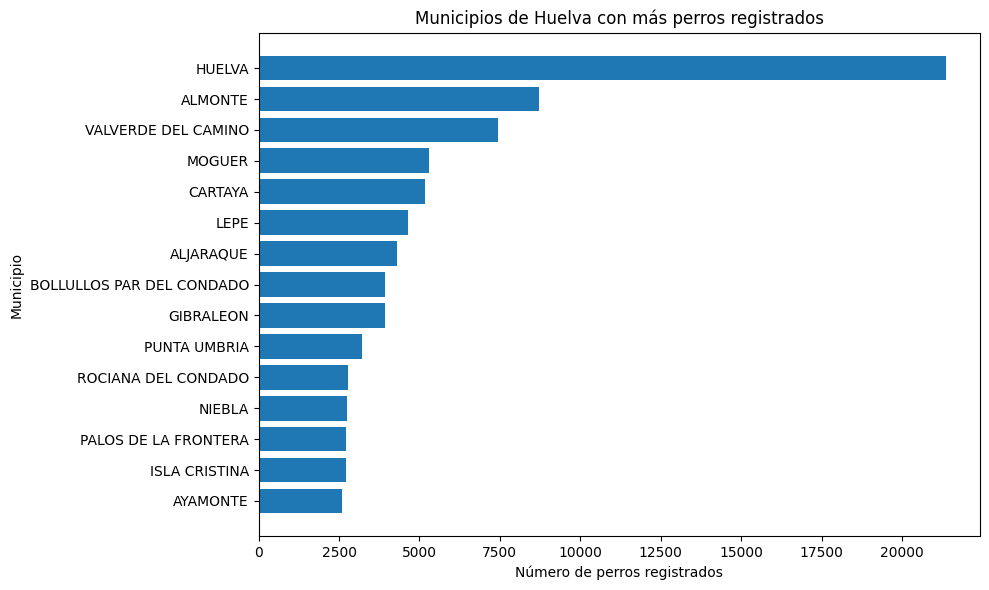

In [23]:
top_15 = resumen_perros_huelva.head(15).sort_values("n_perros")

plt.figure(figsize=(10, 6))
plt.barh(top_15["municipio"], top_15["n_perros"])
plt.xlabel("Número de perros registrados")
plt.ylabel("Municipio")
plt.title("Municipios de Huelva con más perros registrados")
plt.tight_layout()
plt.show()

## Lectura del ranking municipal

El municipio de Huelva concentra el mayor número absoluto de perros registrados en la provincia. Sin embargo, este ranking está condicionado por el tamaño poblacional de cada municipio.

Por tanto, el siguiente paso del análisis debe ser incorporar la población municipal para calcular una tasa comparable: perros registrados por cada 1.000 habitantes.

In [24]:
import pandas as pd

url_ine_huelva = "https://www.ine.es/jaxiT3/files/t/csv_bdsc/2874.csv"

poblacion_huelva_raw = pd.read_csv(
    url_ine_huelva,
    sep=";",
    encoding="latin1"
)

print(poblacion_huelva_raw.shape)
poblacion_huelva_raw.head()

(7290, 4)


,ï»¿Municipios,Sexo,Periodo,Total
0,21002 Aljaraque,Total,2025,22.737
1,21002 Aljaraque,Total,2024,22.489
2,21002 Aljaraque,Total,2023,22.259
3,21002 Aljaraque,Total,2022,22.078
4,21002 Aljaraque,Total,2021,21.706


In [25]:
poblacion_huelva_raw.columns.tolist()

['ï»¿Municipios', 'Sexo', 'Periodo', 'Total']

In [26]:
poblacion_huelva_raw.columns.tolist()

['ï»¿Municipios', 'Sexo', 'Periodo', 'Total']

In [27]:
poblacion_huelva = poblacion_huelva_raw.copy()

# Normalizar nombres de columnas
poblacion_huelva.columns = (
    poblacion_huelva.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(poblacion_huelva.columns.tolist())
poblacion_huelva.head()

['ï»¿municipios', 'sexo', 'periodo', 'total']


,ï»¿municipios,sexo,periodo,total
0,21002 Aljaraque,Total,2025,22.737
1,21002 Aljaraque,Total,2024,22.489
2,21002 Aljaraque,Total,2023,22.259
3,21002 Aljaraque,Total,2022,22.078
4,21002 Aljaraque,Total,2021,21.706


In [28]:
# Detectar columnas principales
col_municipio = [c for c in poblacion_huelva.columns if "municip" in c][0]
col_sexo = [c for c in poblacion_huelva.columns if "sexo" in c][0]
col_periodo = [c for c in poblacion_huelva.columns if "periodo" in c][0]
col_total = [c for c in poblacion_huelva.columns if "total" in c][0]

print(col_municipio, col_sexo, col_periodo, col_total)

ï»¿municipios sexo periodo total


In [29]:
# Convertir población a número
poblacion_huelva[col_total] = (
    poblacion_huelva[col_total]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
)

poblacion_huelva[col_total] = pd.to_numeric(
    poblacion_huelva[col_total],
    errors="coerce"
)

# Ver periodos disponibles
print("Periodos disponibles:")
print(sorted(poblacion_huelva[col_periodo].dropna().unique())[-10:])

Periodos disponibles:
[np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [30]:
ultimo_periodo = poblacion_huelva[col_periodo].dropna().max()

poblacion_huelva_total = poblacion_huelva[
    (poblacion_huelva[col_periodo] == ultimo_periodo) &
    (poblacion_huelva[col_sexo].str.lower().str.contains("total", na=False))
].copy()

poblacion_huelva_total = poblacion_huelva_total[
    [col_municipio, col_periodo, col_total]
].rename(columns={
    col_municipio: "municipio_ine",
    col_periodo: "anio_poblacion",
    col_total: "poblacion_total"
})

poblacion_huelva_total.head()

,municipio_ine,anio_poblacion,poblacion_total
0,21002 Aljaraque,2025,22737.0
90,"21003 Almendro, El",2025,8620.0
180,21004 Almonaster la Real,2025,1759.0
270,21005 Almonte,2025,24864.0
360,21006 Alosno,2025,3986.0


In [31]:
import re
import unicodedata

def limpiar_texto_municipio(texto):
    if pd.isna(texto):
        return None

    texto = str(texto)

    # Quitar posible código inicial tipo "21002 Aljaraque"
    texto = re.sub(r"^\d+\s+", "", texto)

    # Pasar a mayúsculas
    texto = texto.upper()

    # Quitar tildes
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join([c for c in texto if not unicodedata.combining(c)])

    # Quitar espacios dobles
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto

poblacion_huelva_total["municipio_limpio"] = poblacion_huelva_total["municipio_ine"].apply(limpiar_texto_municipio)

resumen_perros_huelva["municipio_limpio"] = resumen_perros_huelva["municipio"].apply(limpiar_texto_municipio)

poblacion_huelva_total.head()

,municipio_ine,anio_poblacion,poblacion_total,municipio_limpio
0,21002 Aljaraque,2025,22737.0,ALJARAQUE
90,"21003 Almendro, El",2025,8620.0,"ALMENDRO, EL"
180,21004 Almonaster la Real,2025,1759.0,ALMONASTER LA REAL
270,21005 Almonte,2025,24864.0,ALMONTE
360,21006 Alosno,2025,3986.0,ALOSNO


In [32]:
perros_poblacion_huelva = resumen_perros_huelva.merge(
    poblacion_huelva_total,
    on="municipio_limpio",
    how="left"
)

perros_poblacion_huelva.head(20)

,municipio,n_perros,municipio_limpio,municipio_ine,anio_poblacion,poblacion_total
0,HUELVA,21360,HUELVA,21 Huelva,2025.0,535703.0
1,HUELVA,21360,HUELVA,21041 Huelva,2025.0,143215.0
2,ALMONTE,8728,ALMONTE,21005 Almonte,2025.0,24864.0
3,VALVERDE DEL CAMINO,7451,VALVERDE DEL CAMINO,21072 Valverde del Camino,2025.0,12631.0
4,MOGUER,5291,MOGUER,21050 Moguer,2025.0,24083.0
5,CARTAYA,5181,CARTAYA,21021 Cartaya,2025.0,21471.0
6,LEPE,4638,LEPE,21044 Lepe,2025.0,29677.0
7,ALJARAQUE,4315,ALJARAQUE,21002 Aljaraque,2025.0,22737.0
8,BOLLULLOS PAR DEL CONDADO,3924,BOLLULLOS PAR DEL CONDADO,21013 Bollullos Par del Condado,2025.0,14314.0
9,GIBRALEON,3923,GIBRALEON,NaN,NaN,NaN


In [33]:
sin_match = perros_poblacion_huelva[
    perros_poblacion_huelva["poblacion_total"].isna()
]

print("Municipios sin cruce con INE:", len(sin_match))
sin_match[["municipio", "n_perros"]].head(30)

Municipios sin cruce con INE: 84


,municipio,n_perros
9,GIBRALEON,3923
10,PUNTA UMBRIA,3222
25,SAN BARTOLOME DE LA TORRE,1898
29,PUEBLA DE GUZMAN,1506
34,CALAÑAS,1314
36,CORRALES,1163
39,"ROCIO, EL",1080
40,MAZAGON,1071
44,ALAJAR,794
47,"CERRO DE ANDEVALO, EL",750


In [34]:
perros_poblacion_huelva["perros_por_1000_hab"] = (
    perros_poblacion_huelva["n_perros"] /
    perros_poblacion_huelva["poblacion_total"] *
    1000
)

perros_poblacion_huelva = perros_poblacion_huelva.sort_values(
    "perros_por_1000_hab",
    ascending=False
)

perros_poblacion_huelva.head(20)

,municipio,n_perros,municipio_limpio,municipio_ine,anio_poblacion,poblacion_total,perros_por_1000_hab
21,LUCENA DEL PUERTO,2264,LUCENA DEL PUERTO,21046 Lucena del Puerto,2025.0,339.0,6678.466077
26,VILLARRASA,1704,VILLARRASA,21077 Villarrasa,2025.0,2103.0,810.271041
32,MANZANILLA,1431,MANZANILLA,21047 Manzanilla,2025.0,2214.0,646.341463
12,NIEBLA,2740,NIEBLA,21053 Niebla,2025.0,4268.0,641.986879
41,ROSAL DE LA FRONTERA,1030,ROSAL DE LA FRONTERA,21062 Rosal de la Frontera,2025.0,1676.0,614.558473
45,HIGUERA DE LA SIERRA,774,HIGUERA DE LA SIERRA,21038 Higuera de la Sierra,2025.0,1292.0,599.071207
3,VALVERDE DEL CAMINO,7451,VALVERDE DEL CAMINO,21072 Valverde del Camino,2025.0,12631.0,589.897870
51,PAYMOGO,655,PAYMOGO,21057 Paymogo,2025.0,1132.0,578.621908
37,"CAMPILLO, EL",1145,"CAMPILLO, EL","21018 Campillo, El",2025.0,2003.0,571.642536
58,CALA,582,CALA,21016 Cala,2025.0,1106.0,526.220615


In [35]:
aljaraque_tasa = perros_poblacion_huelva[
    perros_poblacion_huelva["municipio_limpio"].str.contains("ALJARAQUE", na=False)
]

aljaraque_tasa

,municipio,n_perros,municipio_limpio,municipio_ine,anio_poblacion,poblacion_total,perros_por_1000_hab
7,ALJARAQUE,4315,ALJARAQUE,21002 Aljaraque,2025.0,22737.0,189.778775


In [36]:
from IPython.display import Markdown, display

fila = aljaraque_tasa.iloc[0]

n_perros = int(fila["n_perros"])
poblacion = int(fila["poblacion_total"])
tasa = fila["perros_por_1000_hab"]
anio = fila["anio_poblacion"]

texto = f"""
## Perros registrados por habitante en Aljaraque

Aljaraque cuenta con **{n_perros:,} perros registrados** y una población municipal de **{poblacion:,} habitantes** según el INE para el periodo **{anio}**.

Esto equivale a **{tasa:.1f} perros registrados por cada 1.000 habitantes**.
""".replace(",", ".")

display(Markdown(texto))


## Perros registrados por habitante en Aljaraque

Aljaraque cuenta con **4.315 perros registrados** y una población municipal de **22.737 habitantes** según el INE para el periodo **2025.0**.

Esto equivale a **189.8 perros registrados por cada 1.000 habitantes**.


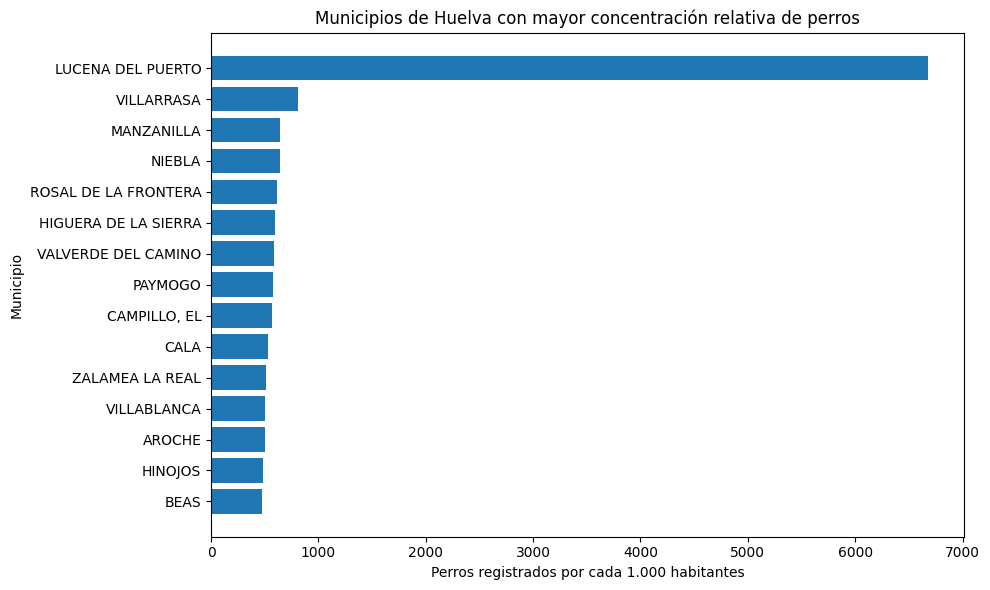

In [37]:
top_15_tasa = perros_poblacion_huelva.head(15).sort_values("perros_por_1000_hab")

plt.figure(figsize=(10, 6))
plt.barh(top_15_tasa["municipio"], top_15_tasa["perros_por_1000_hab"])
plt.xlabel("Perros registrados por cada 1.000 habitantes")
plt.ylabel("Municipio")
plt.title("Municipios de Huelva con mayor concentración relativa de perros")
plt.tight_layout()
plt.show()

In [38]:
perros_poblacion_huelva.to_csv("perros_huelva_poblacion_tasa.csv", index=False)

print("Archivo creado: perros_huelva_poblacion_tasa.csv")

Archivo creado: perros_huelva_poblacion_tasa.csv


In [40]:
perros_poblacion_huelva[
    ["municipio", "n_perros", "poblacion_total", "perros_por_1000_hab"]
].head(20)

,municipio,n_perros,poblacion_total,perros_por_1000_hab
21,LUCENA DEL PUERTO,2264,339.0,6678.466077
26,VILLARRASA,1704,2103.0,810.271041
32,MANZANILLA,1431,2214.0,646.341463
12,NIEBLA,2740,4268.0,641.986879
41,ROSAL DE LA FRONTERA,1030,1676.0,614.558473
45,HIGUERA DE LA SIERRA,774,1292.0,599.071207
3,VALVERDE DEL CAMINO,7451,12631.0,589.897870
51,PAYMOGO,655,1132.0,578.621908
37,"CAMPILLO, EL",1145,2003.0,571.642536
58,CALA,582,1106.0,526.220615


In [41]:
perros_poblacion_huelva[
    ["municipio", "n_perros", "poblacion_total", "perros_por_1000_hab"]
].sort_values("perros_por_1000_hab", ascending=False).head(20)

,municipio,n_perros,poblacion_total,perros_por_1000_hab
21,LUCENA DEL PUERTO,2264,339.0,6678.466077
26,VILLARRASA,1704,2103.0,810.271041
32,MANZANILLA,1431,2214.0,646.341463
12,NIEBLA,2740,4268.0,641.986879
41,ROSAL DE LA FRONTERA,1030,1676.0,614.558473
45,HIGUERA DE LA SIERRA,774,1292.0,599.071207
3,VALVERDE DEL CAMINO,7451,12631.0,589.897870
51,PAYMOGO,655,1132.0,578.621908
37,"CAMPILLO, EL",1145,2003.0,571.642536
58,CALA,582,1106.0,526.220615


| municipio | n_perros | poblacion_total | perros_por_1000_hab |
|---|---:|---:|---:|
| Aljaraque | 4.315 | ... | ... |

In [42]:
perros_poblacion_huelva[
    perros_poblacion_huelva["municipio"].str.upper().str.contains("ALJARAQUE", na=False)
][["municipio", "n_perros", "poblacion_total", "perros_por_1000_hab"]]

,municipio,n_perros,poblacion_total,perros_por_1000_hab
7,ALJARAQUE,4315,22737.0,189.778775


In [43]:
from IPython.display import Markdown, display

fila = perros_poblacion_huelva[
    perros_poblacion_huelva["municipio"].str.upper().str.contains("ALJARAQUE", na=False)
].iloc[0]

n_perros = int(fila["n_perros"])
poblacion = int(fila["poblacion_total"])
tasa = fila["perros_por_1000_hab"]

texto = f"""
## Resultado normalizado: Aljaraque

Aljaraque cuenta con **{n_perros:,} perros registrados** y una población de **{poblacion:,} habitantes**.

Esto equivale a **{tasa:.1f} perros registrados por cada 1.000 habitantes**.
""".replace(",", ".")

display(Markdown(texto))


## Resultado normalizado: Aljaraque

Aljaraque cuenta con **4.315 perros registrados** y una población de **22.737 habitantes**.

Esto equivale a **189.8 perros registrados por cada 1.000 habitantes**.


# 4. Relación entre renta municipal y perros registrados

En este apartado se analiza si existe una relación descriptiva entre la renta media municipal y la concentración de perros registrados por cada 1.000 habitantes.

La variable de renta se obtiene del Atlas de Distribución de Renta de los Hogares del INE. La variable de perros por cada 1.000 habitantes se ha calculado previamente a partir de los datos de RAIA y la población municipal del INE.

La pregunta que se quiere responder es:

**¿Los municipios con mayor renta media presentan una mayor concentración relativa de perros registrados?**